In [292]:
#0:30
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import tight_layout
from sklearn.preprocessing import MinMaxScaler


In [293]:
df=pd.read_csv("../docs/newDocs/csv/CC GENERAL.csv",na_values=['-',' ','','/','null','NA'])

In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [295]:
#jedina za sada koja treba odmah da se izbaci je CUST_id jer je to id i nije nam potreban u modelu
df.drop(columns="CUST_ID",inplace=True)

In [296]:
df.isna().sum()
#CREDIT_LIMIT ima 1 NA vrednost
#MINIMUM_PAYMENTS ova ima 313 NA vrednosti


BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [297]:
df['MINIMUM_PAYMENTS'].count()
# ima 8637 redova i 313 Na vre
procenatNa=313/8637
procenatNa #kako je procenat mali ostavljamo je i gledamo raspdoelu

0.03623943498900081

In [298]:
from scipy.stats import shapiro

stat,p=shapiro(df['MINIMUM_PAYMENTS'].dropna())
if p<0.05:
    print("nema normalnu raspodelu")
else:
    print("ima normalnu")

nema normalnu raspodelu


C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8637.
  res = hypotest_fun_out(*samples, **kwds)


In [299]:
#kako kolona nema normalnu raspodelu popunjavamo je medijanom
df['MINIMUM_PAYMENTS']=df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [300]:
df['MINIMUM_PAYMENTS'].isna().sum()#sada ima 0 NAN vrednosti

np.int64(0)

In [301]:
from scipy.stats import shapiro

stat,p=shapiro(df['CREDIT_LIMIT'].dropna())
if p<0.05:
    print("nema normalnu raspodelu")
else:
    print("ima normalnu")

nema normalnu raspodelu


C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8949.
  res = hypotest_fun_out(*samples, **kwds)


In [302]:
df['CREDIT_LIMIT']=df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())# kako i ova kolona nema normalnu raspodelu popunjavamo sa mediajnom

In [303]:
df.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [304]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [305]:
df.drop(columns="ONEOFF_PURCHASES",inplace=True)
#na osnovu korelacione matrice izbacamo one koje imaju veliku korelaciju ova ima sa purchase

In [306]:
df.drop(columns="PURCHASES_TRX",inplace=True)

In [307]:
df.drop(columns="CASH_ADVANCE_TRX",inplace=True)

In [308]:
df.drop(columns="INSTALLMENTS_PURCHASES",inplace=True)

In [309]:
df.drop(columns="PURCHASES_FREQUENCY",inplace=True)

In [310]:
df.drop(columns="CASH_ADVANCE_FREQUENCY",inplace=True)

In [311]:
df.drop(columns="BALANCE_FREQUENCY",inplace=True)#dropano zbog winsorize

In [312]:
df.drop(columns="MINIMUM_PAYMENTS",inplace=True)#dropano zbog winsorize
df.drop(columns="PRC_FULL_PAYMENT",inplace=True)#dropano zbog winsorize
df.drop(columns="TENURE",inplace=True)#dropano zbog winsorize

In [313]:
df.drop(columns="PAYMENTS",inplace=True)#sve ove kolone iznad koje su dropane su na matrici korelacije prikazale veliku korelaciju sa nekom drugom i zato droppovane

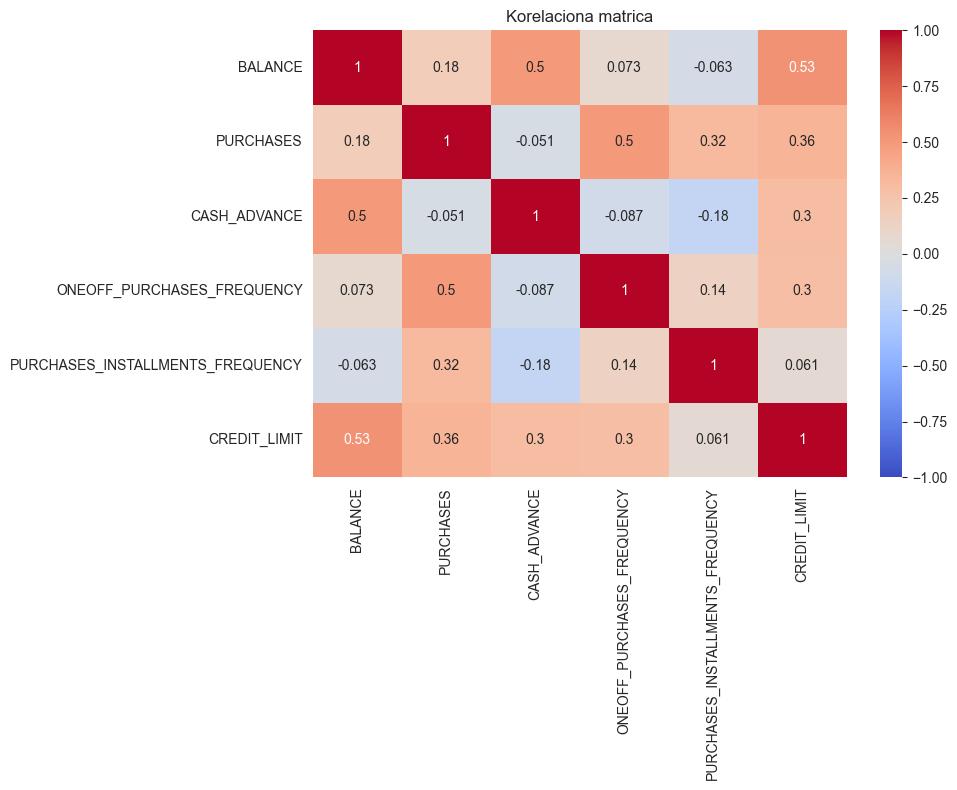

In [314]:
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [315]:
df.describe().round(2) # vidimo da vrednosti nemaju istu raspodelu moracemo da je sklariamo ... prvo da vidim ooutliere ...

,BALANCE,PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CREDIT_LIMIT
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00
mean,1564.47,1003.20,978.87,0.20,0.36,4494.28
std,2081.53,2136.63,2097.16,0.30,0.40,3638.65
min,0.00,0.00,0.00,0.00,0.00,50.00
25%,128.28,39.64,0.00,0.00,0.00,1600.00
50%,873.39,361.28,0.00,0.08,0.17,3000.00
75%,2054.14,1110.13,1113.82,0.30,0.75,6500.00
max,19043.14,49039.57,47137.21,1.00,1.00,30000.00


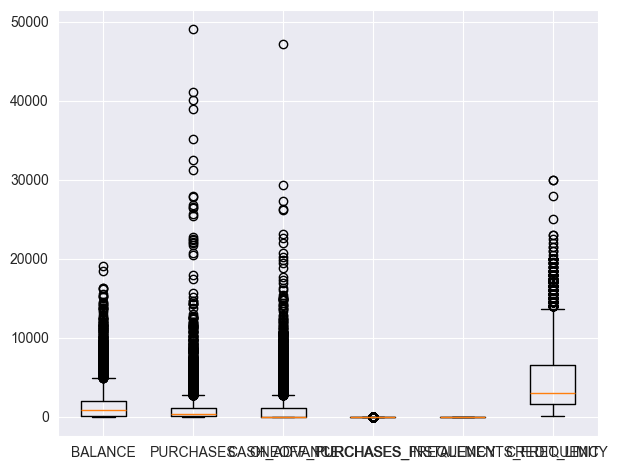

In [316]:
plt.figure()
plt.boxplot(x=df,tick_labels=df.columns)
plt.tight_layout()
plt.show()

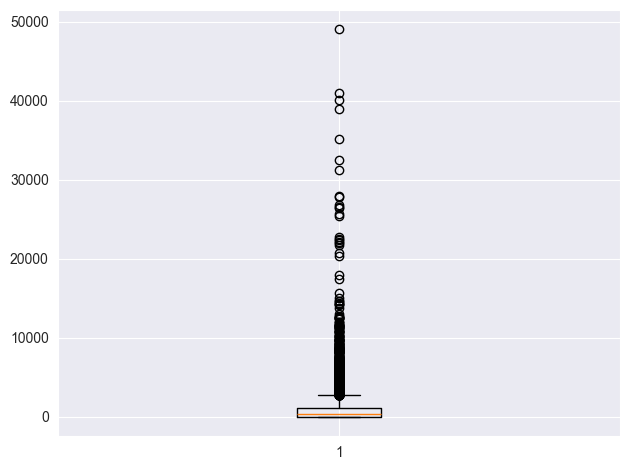

In [317]:
plt.figure()
plt.boxplot(x=df['PURCHASES'])
plt.tight_layout()
plt.show()

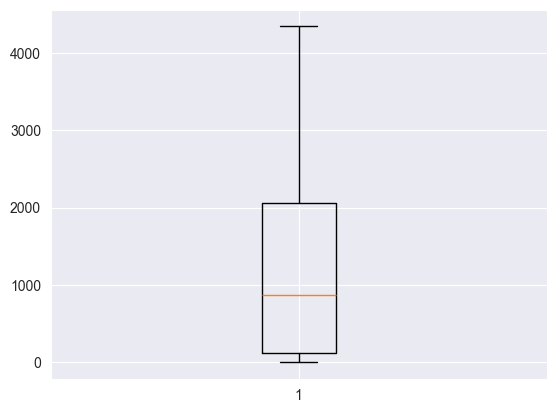

In [318]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['BALANCE'], limits=[0,0.10])
plt.boxplot(wins)
plt.show()

In [319]:
df['BALANCE']=wins

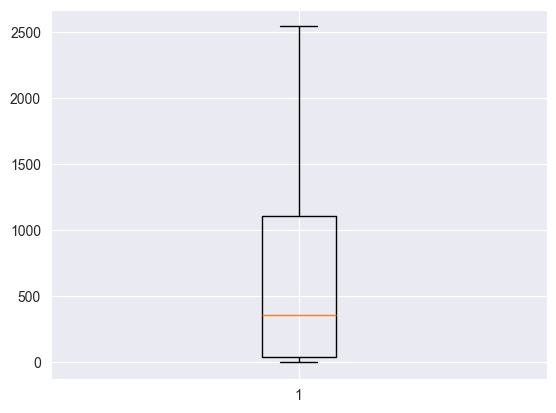

In [320]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['PURCHASES'], limits=[0,0.10])
plt.boxplot(wins)
plt.show()

In [321]:
df['PURCHASES']=wins

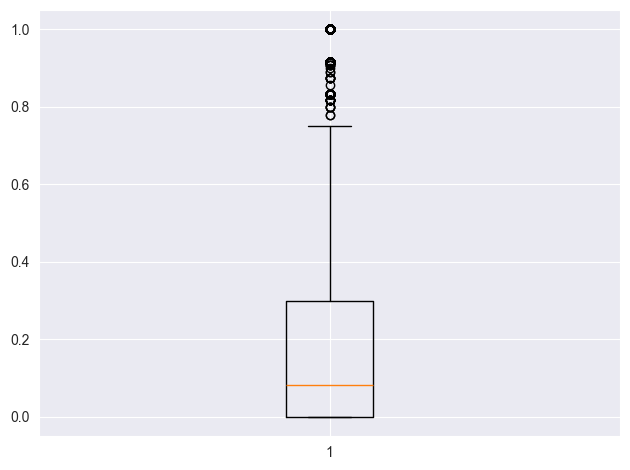

In [322]:
plt.figure()
plt.boxplot(x=df['ONEOFF_PURCHASES_FREQUENCY'])
plt.tight_layout()
plt.show()

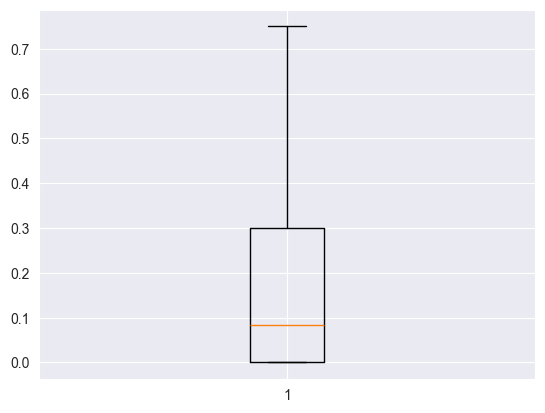

In [323]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['ONEOFF_PURCHASES_FREQUENCY'], limits=[0,0.10])
plt.boxplot(wins)
plt.show()

In [324]:
df['ONEOFF_PURCHASES_FREQUENCY']=wins

In [325]:
df['MINIMUM_PAYMENTS']=wins

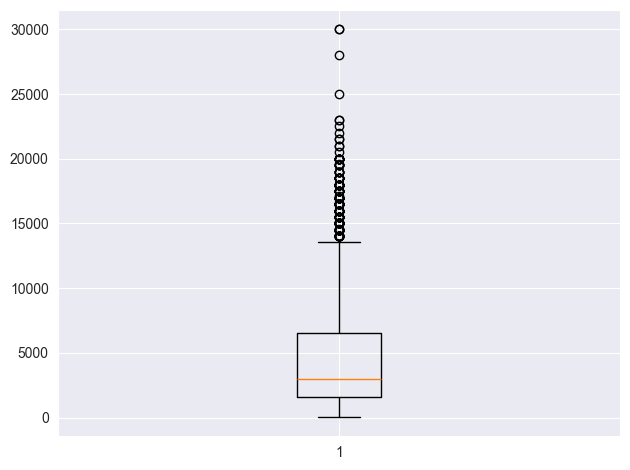

In [326]:
plt.figure()
plt.boxplot(x=df['CREDIT_LIMIT'])
plt.tight_layout()
plt.show()

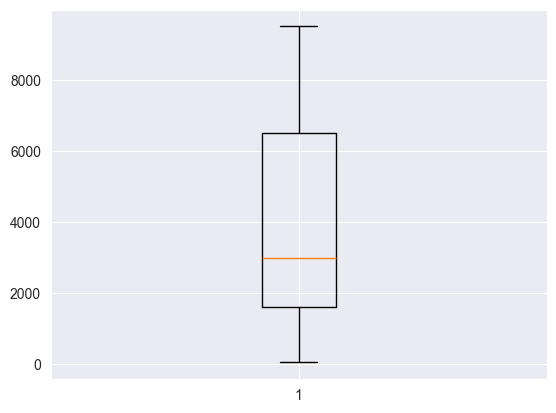

In [327]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['CREDIT_LIMIT'], limits=[0,0.1])
plt.boxplot(wins)
plt.show()

In [328]:
df['CREDIT_LIMIT']=wins

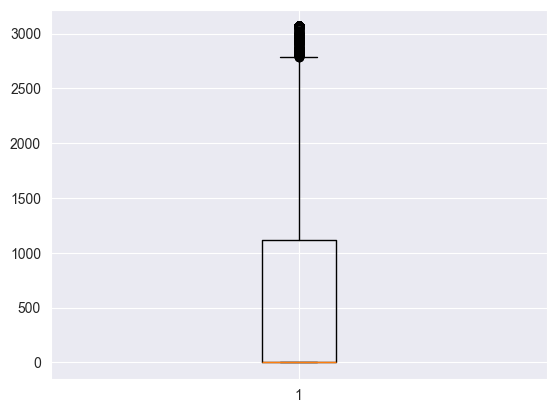

In [329]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['CASH_ADVANCE'], limits=[0,0.1])
plt.boxplot(wins)
plt.show()

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   PURCHASES                         8950 non-null   float64
 2   CASH_ADVANCE                      8950 non-null   float64
 3   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 4   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 5   CREDIT_LIMIT                      8950 non-null   float64
 6   MINIMUM_PAYMENTS                  8950 non-null   float64
dtypes: float64(7)
memory usage: 489.6 KB


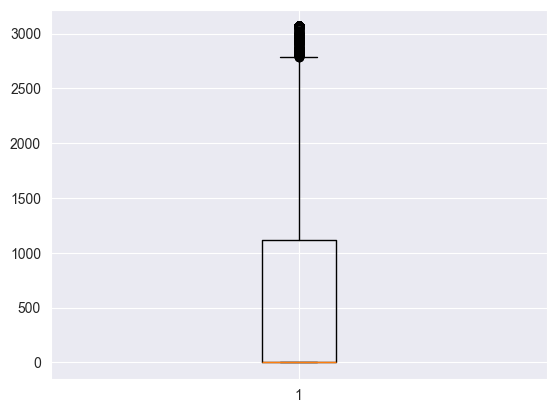

In [331]:
from scipy.stats._mstats_basic import winsorize

wins=winsorize(a=df['CASH_ADVANCE'], limits=[0,0.1])
plt.boxplot(wins)
plt.show()
df.drop(columns='CASH_ADVANCE',inplace=True)

In [332]:
df.describe()#skalaricemo sve na minmax jer vise nema outliera

,BALANCE,PURCHASES,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CREDIT_LIMIT,MINIMUM_PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1337.366820,720.740994,0.184773,0.364437,4181.578562,0.184773
std,1420.216948,843.364252,0.255668,0.397448,2857.980818,0.255668
min,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,1600.000000,0.000000
50%,873.385231,361.280000,0.083333,0.166667,3000.000000,0.083333
75%,2054.140036,1110.130000,0.300000,0.750000,6500.000000,0.300000
max,4338.558856,2542.610000,0.750000,1.000000,9500.000000,0.750000


In [333]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [334]:
from sklearn.model_selection import train_test_split


In [335]:
scaler = MinMaxScaler()
df_scaled=pd.DataFrame(data=scaler.fit_transform(df),columns=df.columns)


In [346]:
df_scaled

,BALANCE,PURCHASES,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CREDIT_LIMIT,MINIMUM_PAYMENTS,clusters
0,0.009427,0.037521,0.000000,0.083333,0.100529,0.000000,1
1,0.738141,0.000000,0.000000,0.000000,0.735450,0.000000,1
2,0.575110,0.304085,1.000000,0.000000,0.788360,1.000000,0
3,0.384153,0.589552,0.111111,0.000000,0.788360,0.111111,1
4,0.188476,0.006293,0.111111,0.000000,0.121693,0.111111,1
...,...,...,...,...,...,...,...
8945,0.006568,0.114497,0.000000,0.833333,0.100529,0.000000,1
8946,0.004422,0.117989,0.000000,0.833333,0.100529,0.000000,1
8947,0.005393,0.056792,0.000000,0.666667,0.100529,0.000000,1
8948,0.003102,0.000000,0.000000,0.000000,0.047619,0.000000,1


In [353]:
from scipy.cluster.hierarchy import dendrogram,linkage
dendrogram(linkage(df_scaled, method='ward', metric='euclidean'))

KeyboardInterrupt: 

In [348]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=2).fit(df_scaled)
df['clusters']=clustering.labels_
df_scaled['clusters']=clustering.labels_

In [349]:
df['clusters'].value_counts()

clusters
0    6757
1    2193
Name: count, dtype: int64

In [351]:
print(df.groupby('clusters').mean().round(2))

          BALANCE  PURCHASES  ONEOFF_PURCHASES_FREQUENCY  \
clusters                                                   
0         1227.23     362.60                        0.06   
1         1676.70    1824.22                        0.58   

          PURCHASES_INSTALLMENTS_FREQUENCY  CREDIT_LIMIT  MINIMUM_PAYMENTS  
clusters                                                                    
0                                     0.31       3633.46              0.06  
1                                     0.54       5870.42              0.58  
